# Evaluation of distribution of models on 60km -> 2.2km-4x over Birmingham

In [ ]:
%reload_ext autoreload

%autoreload 2

%reload_ext dotenv
%dotenv

In [ ]:
from mlde_analysis.default_params import *

In [ ]:
# Parameters
desc = "Comparison of diffusion model for CPMGEM-pr paper\nTest split\n12em dataset and models, 60km inputs -> 8.8km outputs, pSTV input variable set\nCompare techniques: diffusion, u-net, bilinear\n"
eval_vars = ["pr"]
derived_variables_config = {}
dataset_configs = {
    "CPM": "bham64_ccpm-4x_12em_psl-sphum4th-temp4th-vort4th_pr",
    "GCM": "bham64_gcm-4x_12em_psl-sphum4th-temp4th-vort4th_pr",
}
split = "test"
ensemble_members = [
    "01",
    "04",
    "05",
    "06",
    "07",
    "08",
    "09",
    "10",
    "11",
    "12",
    "13",
    "15",
]
samples_per_run = 6
sample_configs = {
    "CPM": [
        {
            "label": "CPMGEM_cCPM",
            "sample_specs": [
                {
                    "fq_model_id": "score-sde/subvpsde/ukcp_local_pr_12em_cncsnpp_continuous/bham-4x_12em_pSTV",
                    "checkpoint": "epoch_20",
                    "input_xfm": "bham64_ccpm-4x_12em_psl-sphum4th-temp4th-vort4th_pr-stan",
                    "dataset": "bham64_ccpm-4x_12em_psl-sphum4th-temp4th-vort4th_pr",
                    "variables": ["pr"],
                }
            ],
            "deterministic": False,
            "CCS": True,
            "color": "tab:blue",
            "order": 11,
        },
        {
            "label": "U-Net_cCPM",
            "sample_specs": [
                {
                    "fq_model_id": "score-sde/deterministic/ukcp_local_pr_12em_plain_unet/bham_pSTV-ema-gradcl-256-batch",
                    "checkpoint": "epoch_100",
                    "input_xfm": "bham64_ccpm-4x_12em_psl-sphum4th-temp4th-vort4th_pr-stan",
                    "dataset": "bham64_ccpm-4x_12em_psl-sphum4th-temp4th-vort4th_pr",
                    "variables": ["pr"],
                }
            ],
            "deterministic": True,
            "color": "tab:orange",
            "order": 2,
        },
        {
            "label": "BCSD_cCPM",
            "sample_specs": [
                {
                    "fq_model_id": "bcsd-v1/ukcp_local_pr_12em-ws3",
                    "checkpoint": "epoch-0",
                    "input_xfm": "bham64_ccpm-4x_12em_linpr_pr-bcsd",
                    "dataset": "bham64_ccpm-4x_12em_linpr_pr",
                    "variables": ["pr"],
                }
            ],
            "deterministic": True,
            "color": "tab:red",
            "order": 1,
            "UQ": True,
            "CCS": True,
        },
    ],
    "GCM": [
        {
            "label": "CPMGEM_GCM",
            "sample_specs": [
                {
                    "fq_model_id": "score-sde/subvpsde/ukcp_local_pr_12em_cncsnpp_continuous/bham-4x_12em_pSTV",
                    "checkpoint": "epoch_20",
                    "input_xfm": "bham64_gcm-4x_12em_psl-sphum4th-temp4th-vort4th_pr-pixelmmsstan",
                    "dataset": "bham64_gcm-4x_12em_psl-sphum4th-temp4th-vort4th_pr",
                    "variables": ["pr"],
                }
            ],
            "deterministic": False,
            "CCS": True,
            "UQ": False,
            "color": "tab:green",
            "order": 20,
        }
    ],
}
sample_configs_at_60km = [
    {
        "label": "CPMGEM_GCM@60km",
        "sample_specs": [
            {
                "fq_model_id": "score-sde/subvpsde/ukcp_local_pr_12em_cncsnpp_continuous/bham-4x_12em_pSTV/postprocess/gcm-grid",
                "checkpoint": "epoch_20",
                "input_xfm": "bham64_gcm-4x_12em_psl-sphum4th-temp4th-vort4th_pr-pixelmmsstan",
                "dataset": "bham64_gcm-4x_12em_psl-sphum4th-temp4th-vort4th_pr",
                "variables": ["pr"],
            }
        ],
        "deterministic": False,
    }
]
dataset_configs_at_60km = {
    "CPM": "bham64_ccpm-60km_12em_pr_pr",
    "GCM": "bham64_gcm-60km_12em_rawpr_pr",
}
example_percentiles = {
    "CPM": {
        "DJF Wet": {"percentile": 0.8, "variable": "pr", "season": "DJF"},
        "DJF Wettest": {"percentile": 1, "variable": "pr", "season": "DJF"},
        "JJA Wet": {"percentile": 0.8, "variable": "pr", "season": "JJA"},
        "JJA Wettest": {"percentile": 1, "variable": "pr", "season": "JJA"},
    },
    "GCM": {
        "DJF Wet": {"percentile": 0.8, "variable": "pr", "season": "DJF"},
        "DJF Wettest": {"percentile": 1, "variable": "pr", "season": "DJF"},
        "JJA Wet": {"percentile": 0.8, "variable": "pr", "season": "JJA"},
        "JJA Wettest": {"percentile": 1, "variable": "pr", "season": "JJA"},
    },
}
example_overrides = {"CPM": {"JJA Wet": ["01", "1993-08-01 12:00:00"]}, "GCM": {}}
examples_sample_idxs = [2, 5]
niterations = 30
bootstrap_configs = {"niterations": {"spread-error": 50}}


In [ ]:
import functools
import math
import string

import IPython
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from mlde_analysis.data import prep_eval_data
from mlde_analysis import plot_map
from mlde_analysis.display import pretty_table, VAR_RANGES
from mlde_analysis.distribution import mean_bias, std_bias, stat_bias, plot_freq_density, rms_mean_bias, rms_std_bias, xr_hist, hist_dist, plot_distribution_figure, compute_metrics, DIST_THRESHOLDS
from mlde_analysis.wet_dry import threshold_exceeded_prop_stats, threshold_exceeded_prop, threshold_exceeded_prop_error, threshold_exceeded_prop_change, plot_threshold_exceedence_errors, THRESHOLDS
from mlde_utils import cp_model_rotated_pole
from mlde_analysis import qq_plot, reasonable_quantiles

In [ ]:
matplotlib.rcParams['figure.dpi'] = 300

In [ ]:
IPython.display.Markdown(desc)

Comparison of diffusion model for CPMGEM-pr paper
Test split
12em dataset and models, 60km inputs -> 8.8km outputs, pSTV input variable set
Compare techniques: diffusion, u-net, bilinear


In [ ]:
%reload_ext mlde_analysis.magics 
EVAL_DS, MODELS, CPM_DAS, PRED_DAS, VAR_DAS, MODELLABEL2SPEC = %load_eval_data
EVAL_DS

{'CPM': <xarray.Dataset> Size: 34GB
 Dimensions:                     (model: 3, sample_id: 6, ensemble_member: 12,
                                  time: 3240, grid_latitude: 64,
                                  grid_longitude: 64, bnds: 2)
 Coordinates:
   * ensemble_member             (ensemble_member) <U2 96B '01' '04' ... '15'
   * time                        (time) object 26kB 1981-03-01 12:00:00 ... 20...
     season                      (time) int64 26kB 1 1 1 1 1 1 1 ... 2 2 2 2 2 2
   * grid_latitude               (grid_latitude) float32 256B -2.49 ... 2.55
   * grid_longitude              (grid_longitude) float32 256B 357.9 ... 363.0
     time_period                 (time) <U8 104kB 'historic' ... 'future'
   * model                       (model) object 24B 'CPMGEM_cCPM' ... 'BCSD_cCPM'
     dec_adjusted_year           (time) int64 26kB 1981 1981 1981 ... 2076 2076
     stratum                     (time) <U12 156kB 'historic MAM' ... 'future ...
     tp_season_year         

## Figures: Seasonal distribution

* Frequency Density Histogram of rainfall intensities
* Maps of Mean bias ($\frac{\mu_{sample}-\mu_{CPM}}{\mu_{CPM}}$) over all samples, time and ensemble members
* Std Dev Bias $\frac{\sigma_{sample}}{\sigma_{CPM}}$ over all samples, time and ensemble members

### pr

#### DJF

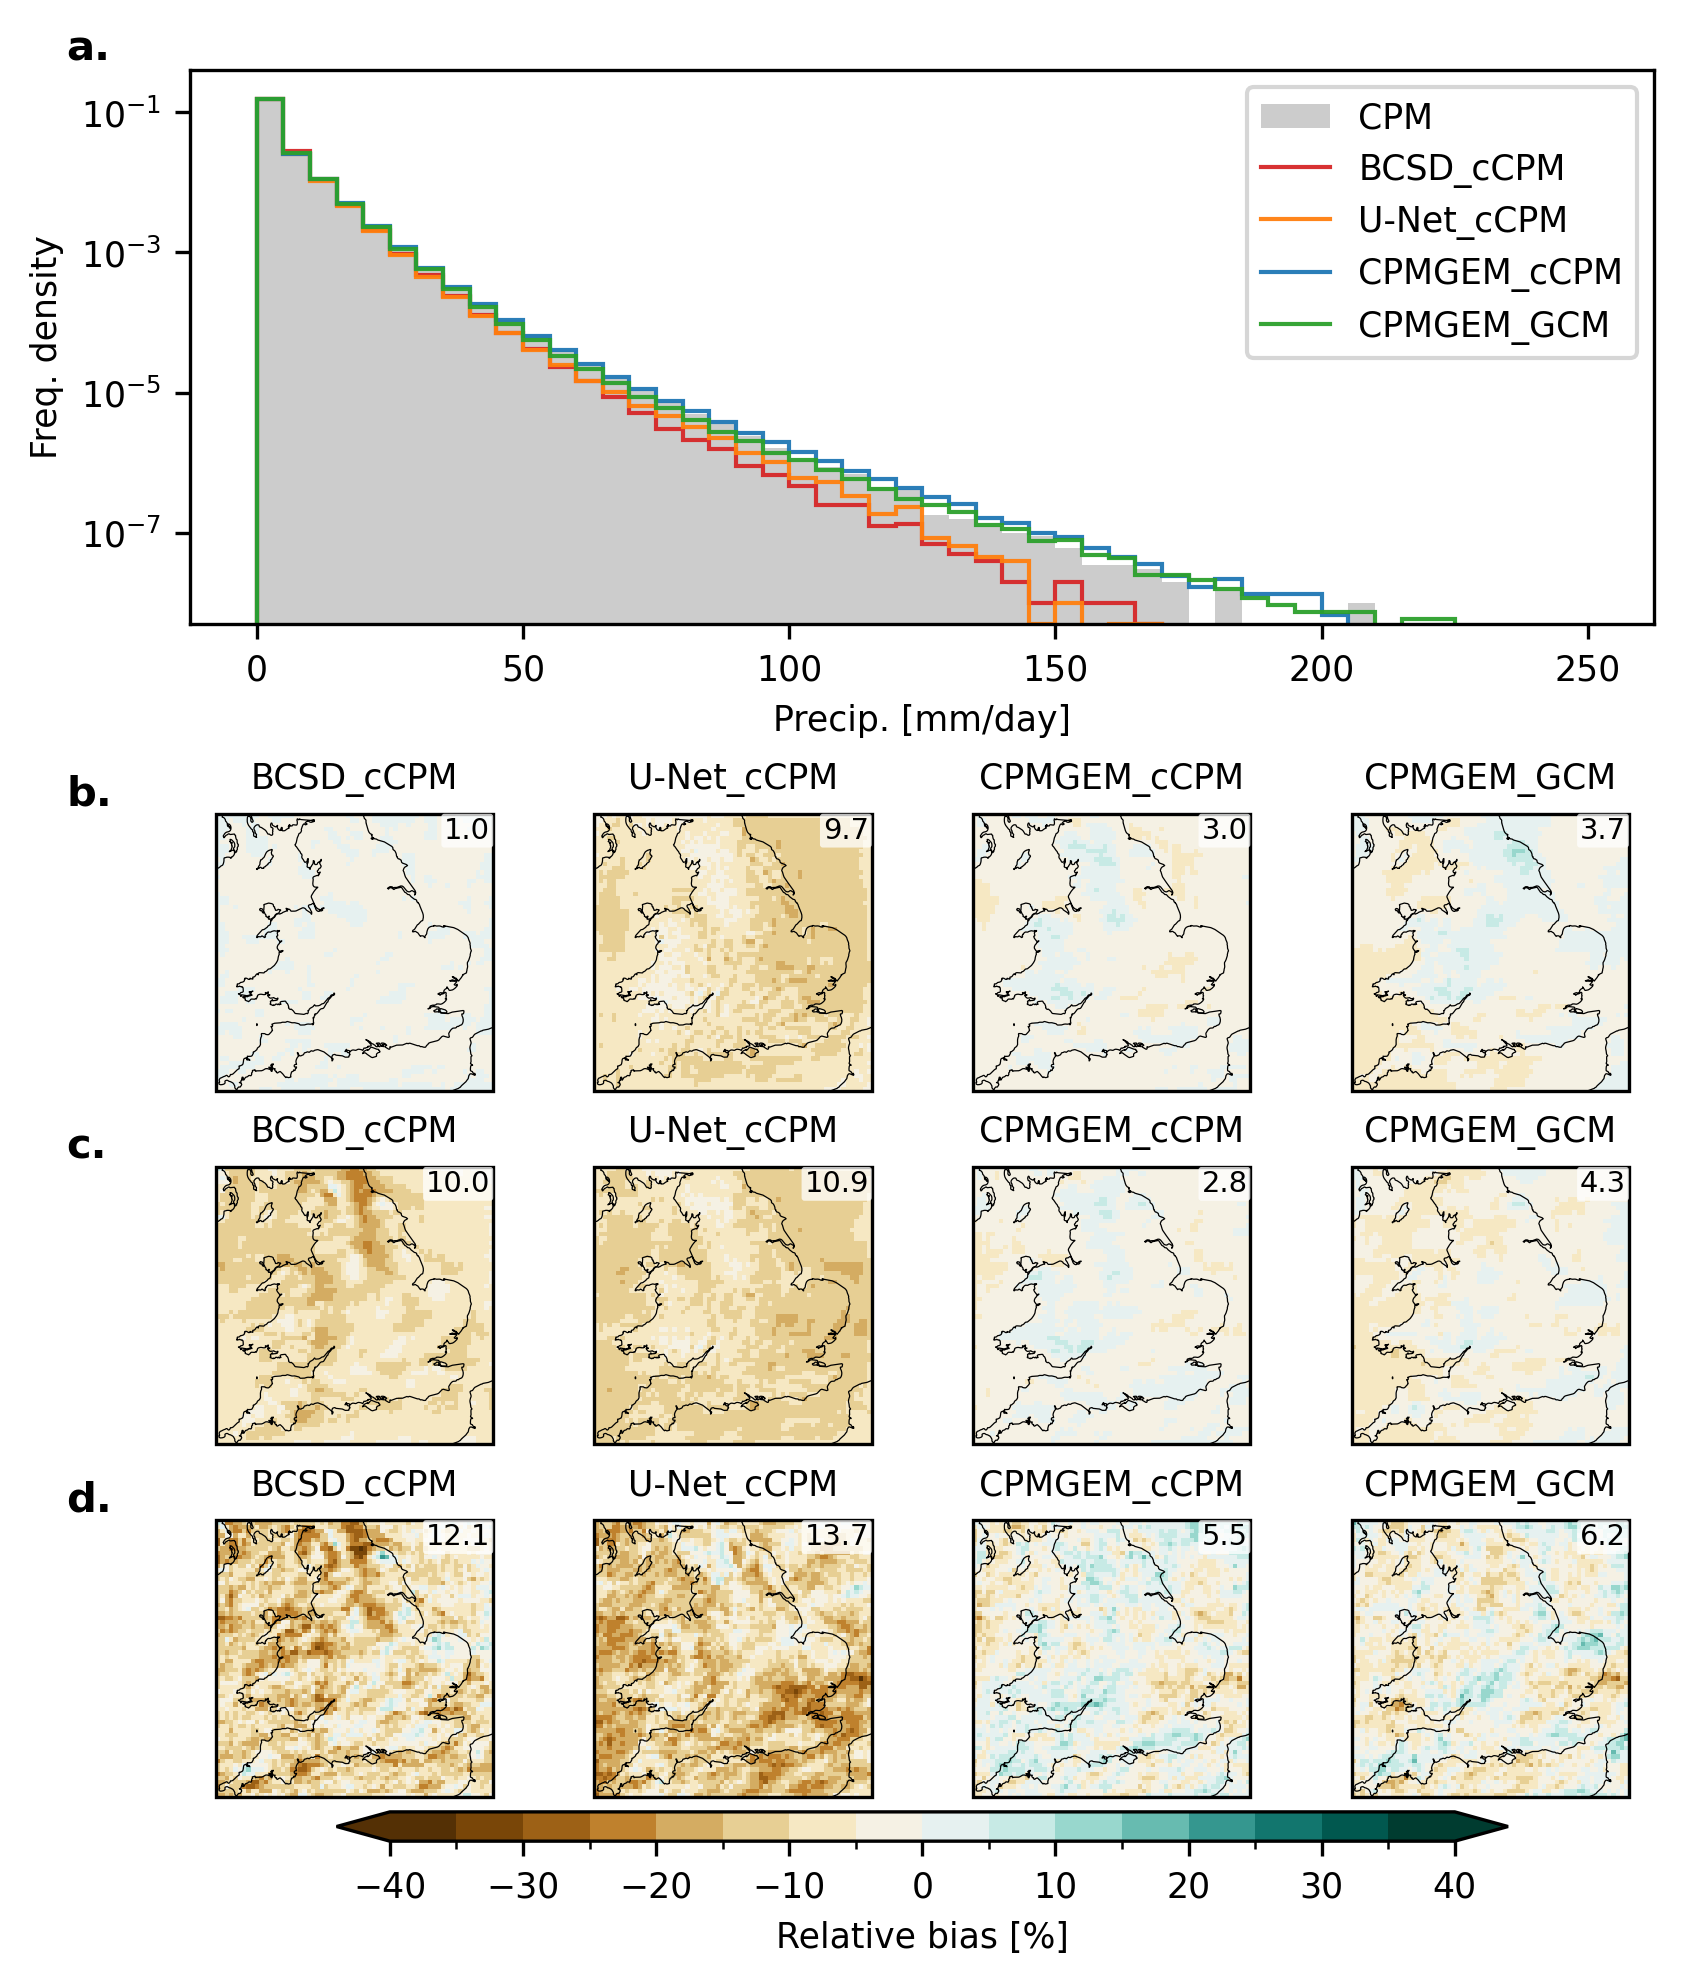

#### JJA

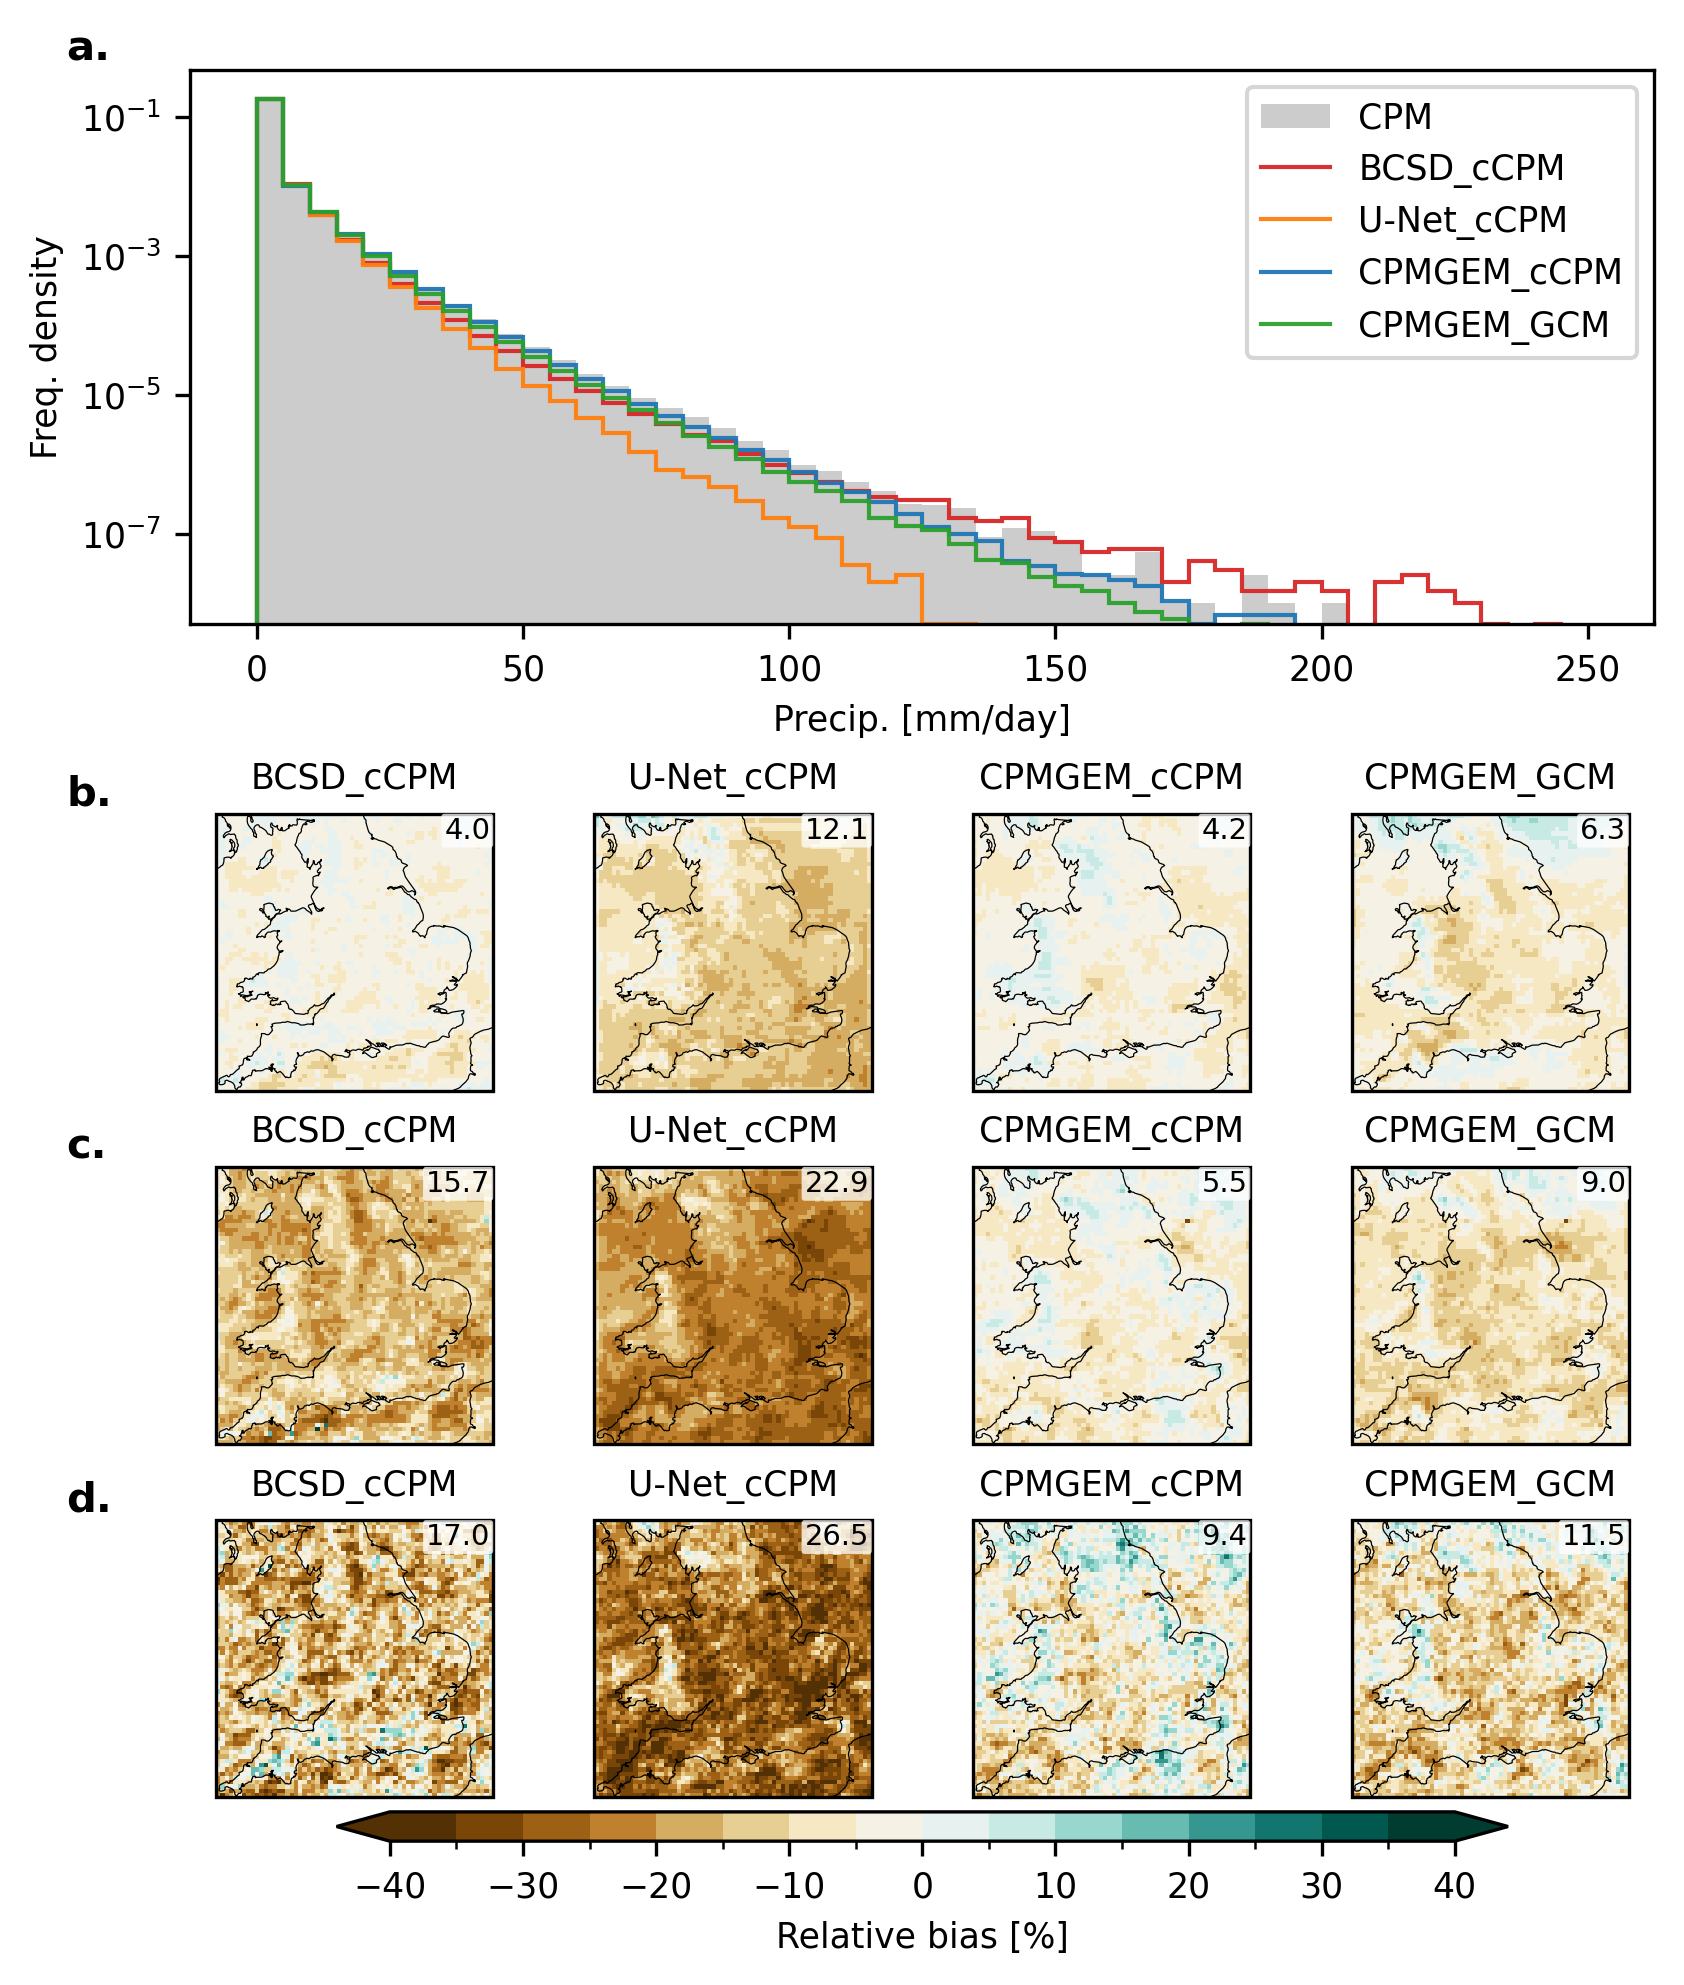

#### MAM

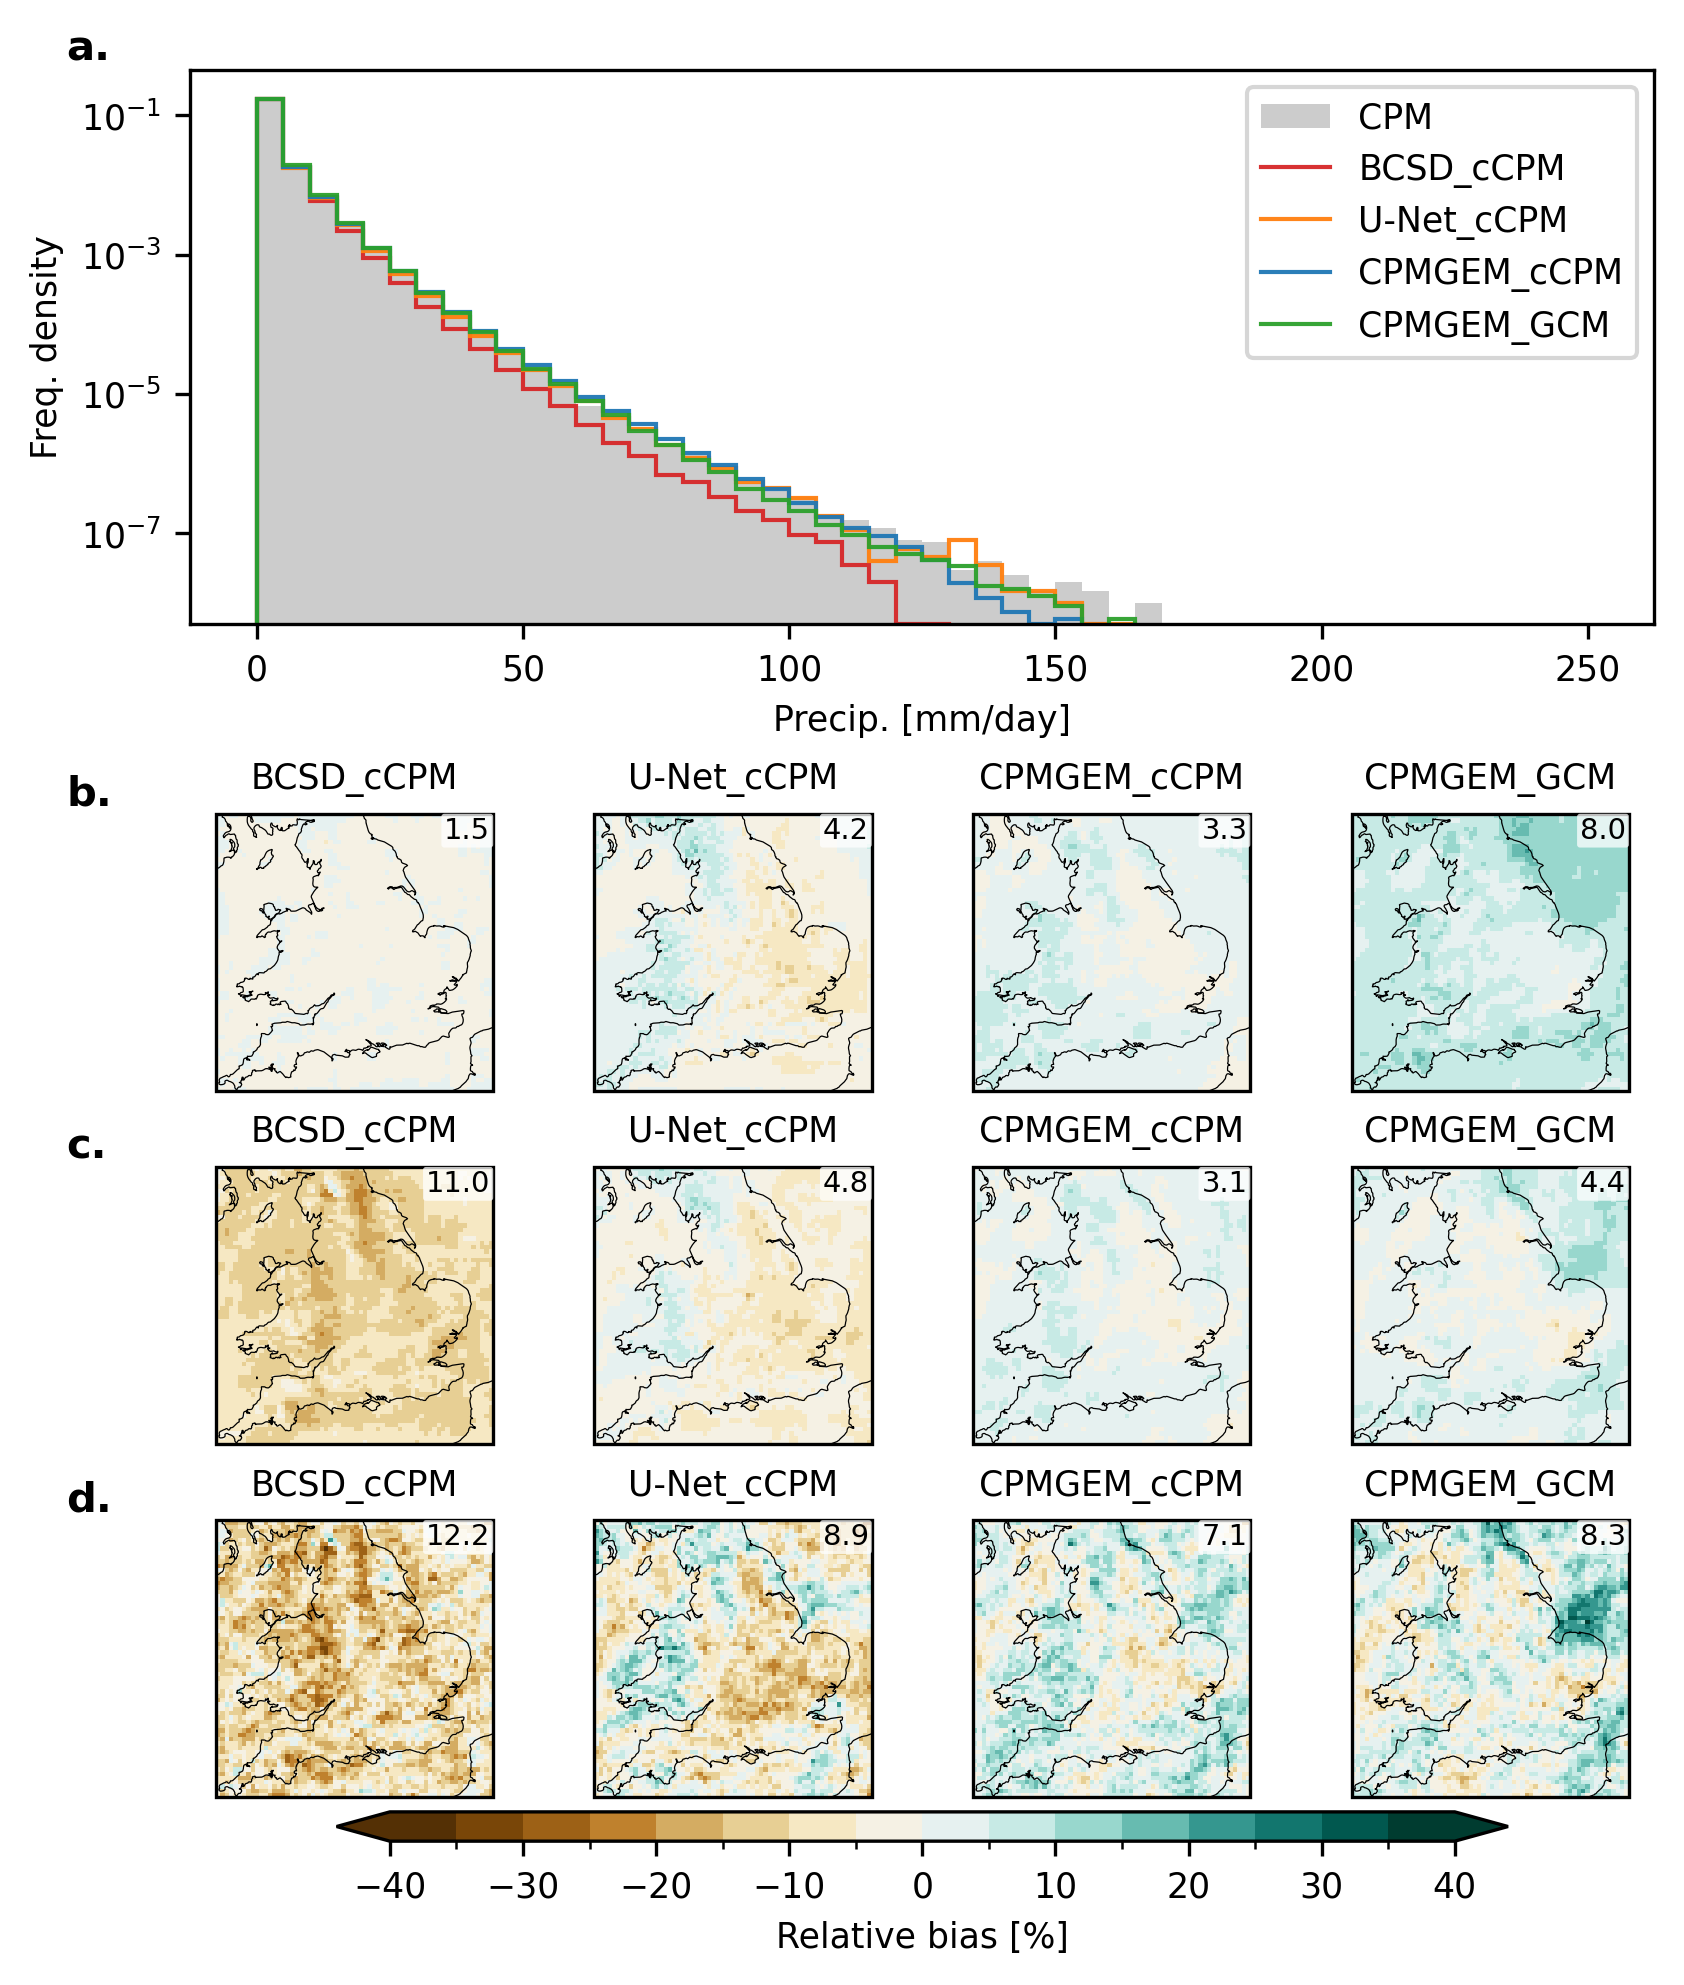

#### SON

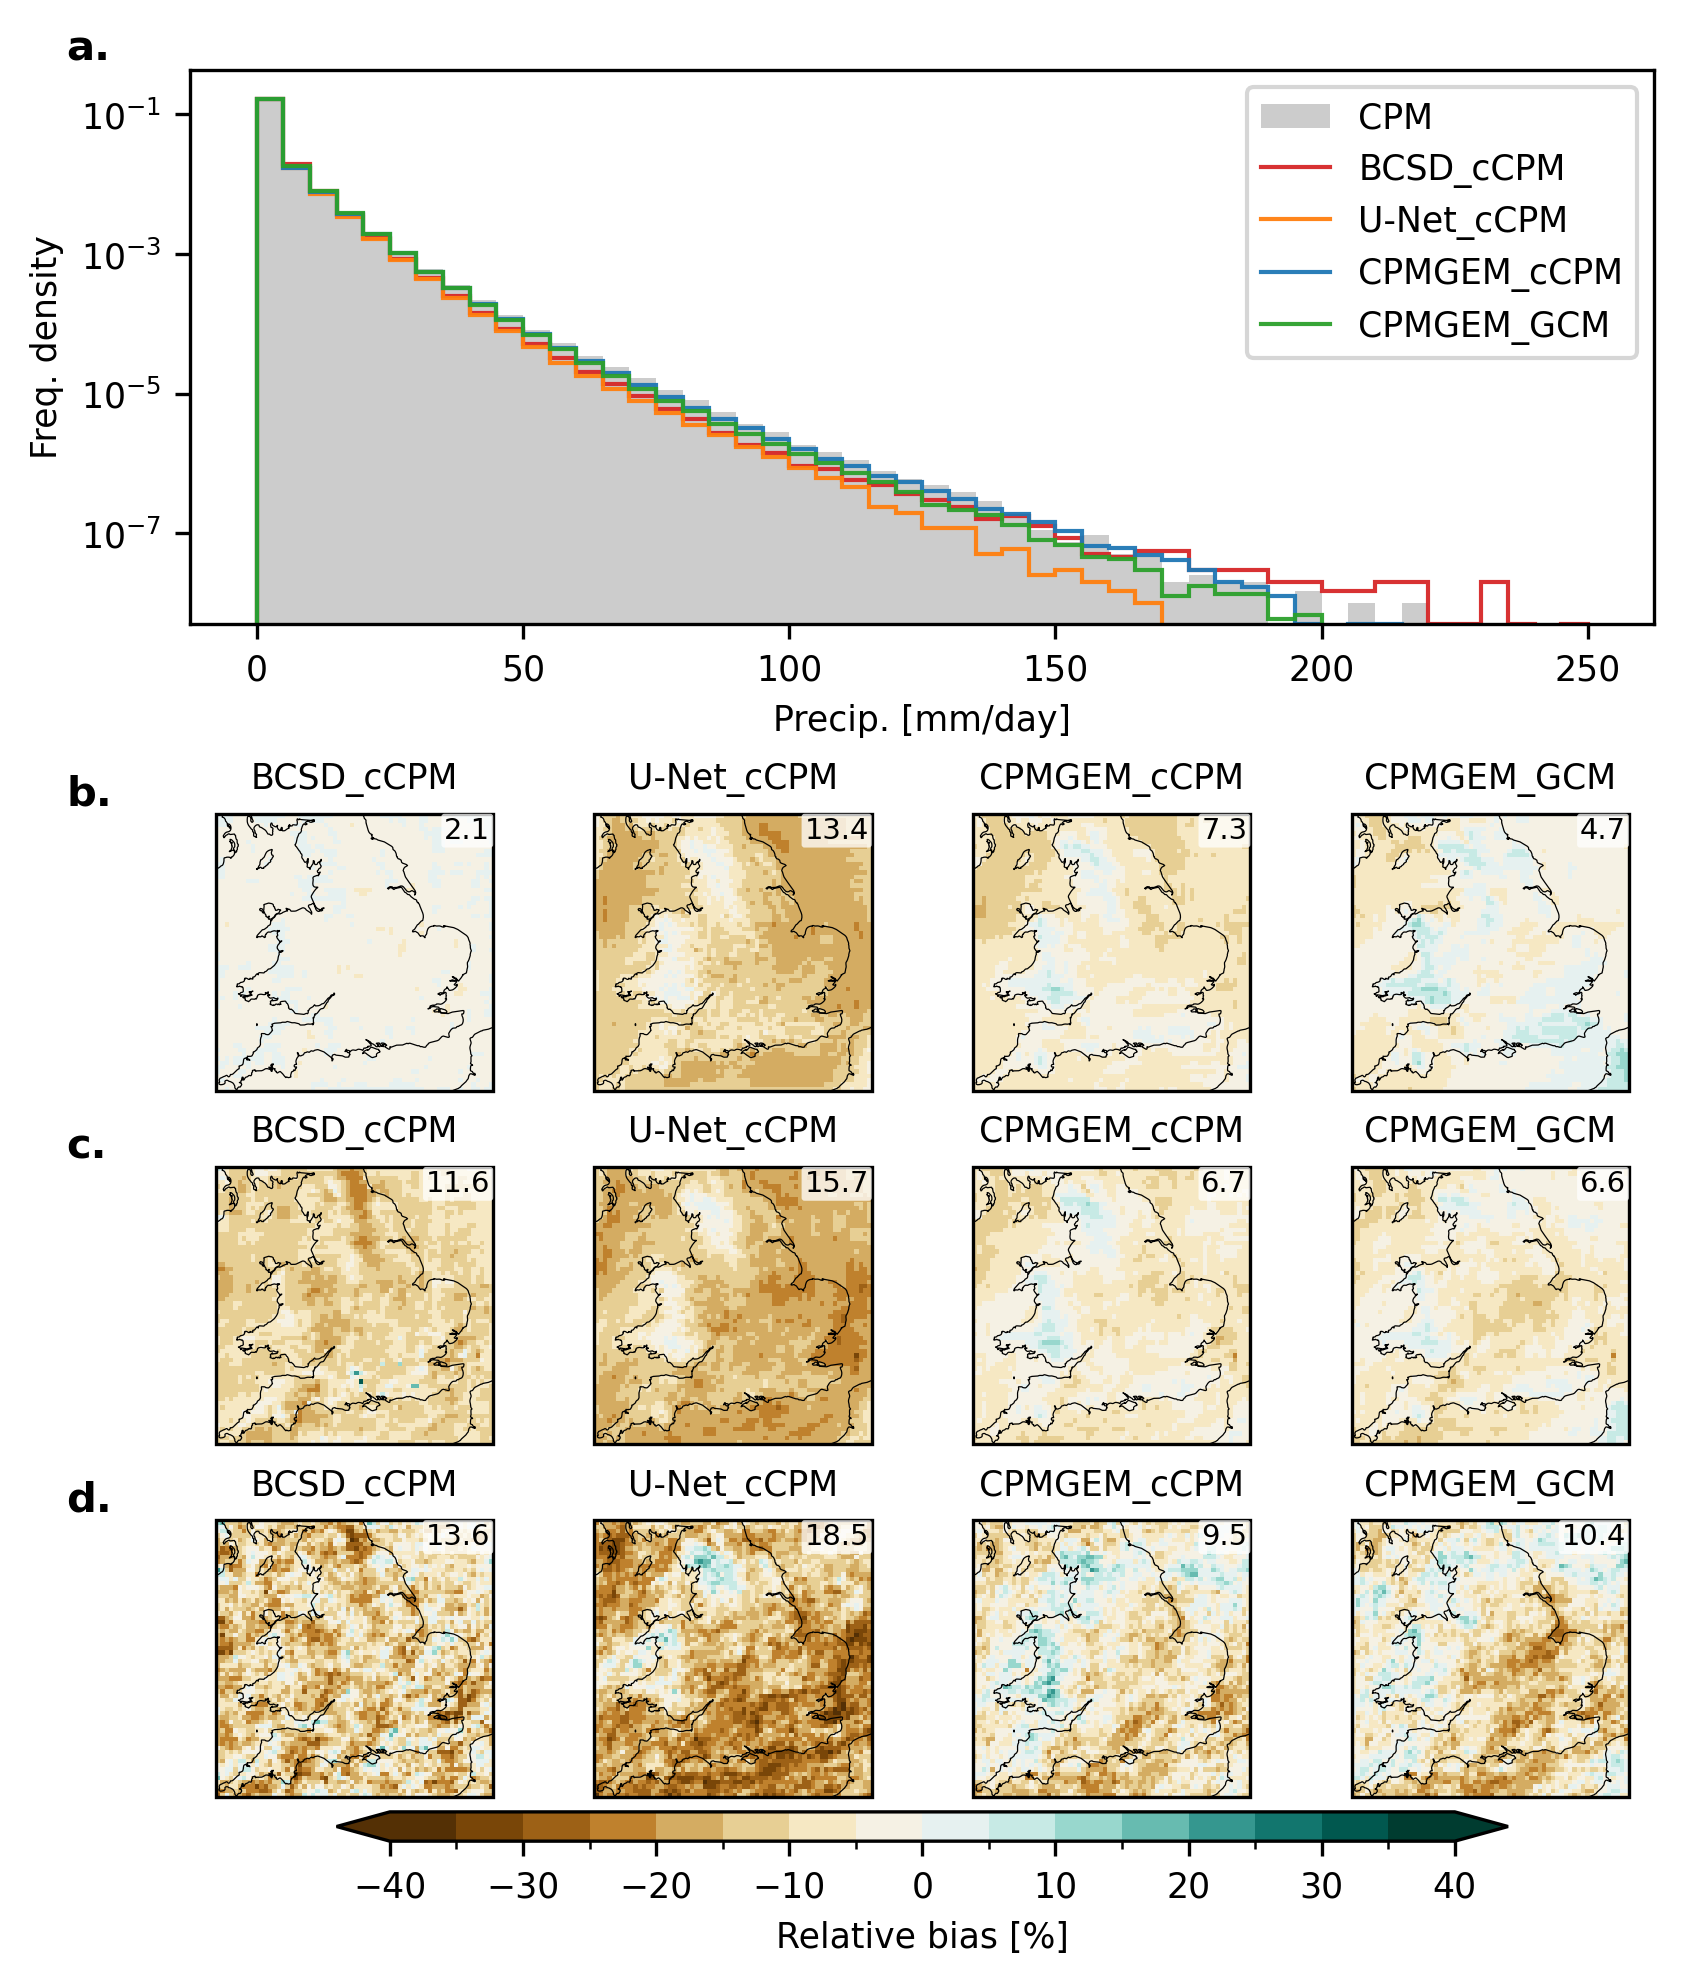

In [ ]:
for var in eval_vars:
    IPython.display.display_markdown(f"### {var}", raw=True)
    for season, season_ds in VAR_DAS[var].groupby("time.season"):
        IPython.display.display_markdown(f"#### {season}", raw=True)
        hist_das = season_ds[f"pred_{var}"]
        cpm_da = season_ds[f"target_{var}"]
        normalize=(var == "pr")
        mean_biases = season_ds[f"pred_{var}"].groupby("model").map(mean_bias, cpm_da=season_ds[f"target_{var}"], normalize=normalize)
        std_biases = season_ds[f"pred_{var}"].groupby("model").map(std_bias, cpm_da=season_ds[f"target_{var}"], normalize=normalize)
        
        f_q999_bias = functools.partial(stat_bias, stat_func=functools.partial(xr.DataArray.quantile, q=0.999))
        q999_biases = season_ds[f"pred_{var}"].groupby("model").map(f_q999_bias, cpm_da=season_ds[f"target_{var}"], normalize=normalize)
        
        bias_kwargs = {"style": f"{var}Bias"}
        for fd_kwargs in [{"yscale": "log"}, {"yscale": "linear"}]:
            if var == "pr" and fd_kwargs["yscale"] == "linear":
                continue
            fig = plt.figure(layout="constrained", figsize=(5.5, 6.5))
            axd = plot_distribution_figure(
                fig,
                hist_das,
                cpm_da,
                mean_biases,
                std_biases,
                q999_biases,
                MODELLABEL2SPEC, 
                hrange=VAR_RANGES[var],
                fd_kwargs=fd_kwargs,
                bias_kwargs=bias_kwargs,
            )
            if var == "relhum150cm":
                axd["Density"].axvline(x=100, color='k', linestyle='--', linewidth=1)
            
        plt.show()

## Seasonal RMS biases and J-S Distances

In [ ]:
for var in eval_vars:
    IPython.display.display_markdown(f"### {var}", raw=True)
    metrics_ds = VAR_DAS[var].groupby("time.season").map(lambda season_ds:compute_metrics(season_ds[f"pred_{var}"], season_ds[f"target_{var}"], thresholds=DIST_THRESHOLDS[var]))
        
    pretty_table(metrics_ds, round=4, dim_order=["season", "model"])

### pr

NaN Count 
 RMS Mean Bias (mm/day) 
 RMS Std Dev Bias (mm/day) 
 RMS Q999 Bias (mm/day) 
 Relative RMS Mean Bias (%) 
 Relative RMS Std Dev Bias (%) 
 Relative RMS Q999 Bias (%) 
 J-S distance 
 Emu > 0.1 
 Emu > 0.1 - CPM > 0.1 
 Emu > 25 
 Emu > 25 - CPM > 25 
 Emu > 75 
 Emu > 75 - CPM > 75 
 Emu > 125 
 Emu > 125 - CPM > 125 
 quantile 
 
 
 season 
 model 
   
   
   
   
   
   
   
   
   
   
   
   
   
   
   
   
   
 
 
 
 
 DJF 
 BCSD_cCPM 
 0 
 0.0371 
 0.5776 
 5.655 
 1.032 
 10.03 
 12.11 
 0.0185 
 0.7884 
 0.1139 
 0.009865 
 -0.003313 
 4.898e-05 
 -7.282e-05 
 1.181e-06 
 -3.24e-06 
 0.999 
 
 
 CPMGEM_GCM 
 0 
 0.1427 
 0.2548 
 2.748 
 3.729 
 4.297 
 6.233 
 0.006307 
 0.6813 
 0.006874 
 0.01205 
 -0.001132 
 0.0001025 
 -1.933e-05 
 5.471e-06 
 1.051e-06 
 0.999 
 
 
 CPMGEM_cCPM 
 0 
 0.1132 
 0.1656 
 2.405 
 3.019 
 2.803 
 5.479 
 0.003183 
 0.6642 
 -0.01024 
 0.01296 
 -0.000222 
 0.000135 
 1.322e-05 
 6.656e-06 
 2.235e-06 
 0.999 
 
 
 U-Net_cCPM 
 0 
 0.3147 
 0.584 
 5.831 
 9.67 
 10.93 
 13.74 
 0.01995 
 0.6856 
 0.01113 
 0.009549 
 -0.00363 
 7.387e-05 
 -4.792e-05 
 1.306e-06 
 -3.115e-06 
 0.999 
 
 
 JJA 
 BCSD_cCPM 
 0 
 0.05543 
 0.6933 
 7.76 
 4.027 
 15.69 
 16.96 
 0.01792 
 0.5124 
 0.1435 
 0.004598 
 -0.002787 
 7.339e-05 
 -3.876e-05 
 7.033e-06 
 1.582e-06 
 0.999 
 
 
 CPMGEM_GCM 
 0 
 0.106 
 0.4091 
 5.413 
 6.291 
 9.018 
 11.53 
 0.007729 
 0.3838 
 0.01482 
 0.006032 
 -0.001353 
 6.065e-05 
 -5.15e-05 
 1.792e-06 
 -3.659e-06 
 0.999 
 
 
 CPMGEM_cCPM 
 0 
 0.06795 
 0.2432 
 4.334 
 4.248 
 5.492 
 9.386 
 0.003163 
 0.3685 
 -0.0004288 
 0.006998 
 -0.0003876 
 8.065e-05 
 -3.15e-05 
 2.541e-06 
 -2.909e-06 
 0.999 
 
 
 U-Net_cCPM 
 0 
 0.1763 
 0.9952 
 11.97 
 12.07 
 22.93 
 26.54 
 0.02444 
 0.4555 
 0.08651 
 0.003604 
 -0.003781 
 1.359e-05 
 -9.856e-05 
 5.023e-08 
 -5.4e-06 
 0.999 
 
 
 MAM 
 BCSD_cCPM 
 0 
 0.03358 
 0.4779 
 4.638 
 1.508 
 11.03 
 12.24 
 0.01727 
 0.6802 
 0.1237 
 0.003716 
 -0.001762 
 1.08e-05 
 -2.002e-05 
 2.512e-08 
 -1.206e-06 
 0.999 
 
 
 CPMGEM_GCM 
 0 
 0.1874 
 0.1772 
 2.697 
 7.967 
 4.392 
 8.292 
 0.01306 
 0.5891 
 0.03259 
 0.005924 
 0.0004458 
 2.571e-05 
 -5.111e-06 
 7.2e-07 
 -5.107e-07 
 0.999 
 
 
 CPMGEM_cCPM 
 0 
 0.09925 
 0.1612 
 2.477 
 3.344 
 3.102 
 7.061 
 0.004475 
 0.5622 
 0.005707 
 0.006054 
 0.0005751 
 3.227e-05 
 1.453e-06 
 5.023e-07 
 -7.284e-07 
 0.999 
 
 
 U-Net_cCPM 
 0 
 0.1091 
 0.2088 
 3.208 
 4.234 
 4.796 
 8.933 
 0.002022 
 0.5841 
 0.02758 
 0.005338 
 -0.0001403 
 2.936e-05 
 -1.457e-06 
 1.055e-06 
 -1.758e-07 
 0.999 
 
 
 SON 
 BCSD_cCPM 
 0 
 0.053 
 0.6617 
 7.136 
 2.136 
 11.61 
 13.62 
 0.01668 
 0.6555 
 0.1354 
 0.009612 
 -0.003828 
 0.0001062 
 -8.909e-05 
 8.138e-06 
 -1.08e-06 
 0.999 
 
 
 CPMGEM_GCM 
 0 
 0.1455 
 0.3705 
 5.348 
 4.682 
 6.631 
 10.41 
 0.006404 
 0.5319 
 0.01172 
 0.01202 
 -0.001422 
 0.0001341 
 -6.122e-05 
 5.651e-06 
 -3.567e-06 
 0.999 
 
 
 CPMGEM_cCPM 
 0 
 0.1925 
 0.3744 
 5.036 
 7.289 
 6.733 
 9.529 
 0.00918 
 0.5077 
 -0.0125 
 0.0121 
 -0.001338 
 0.0001588 
 -3.648e-05 
 8.49e-06 
 -7.284e-07 
 0.999 
 
 
 U-Net_cCPM 
 0 
 0.3373 
 0.8469 
 9.327 
 13.37 
 15.72 
 18.54 
 0.02185 
 0.536 
 0.01581 
 0.009157 
 -0.004283 
 8.578e-05 
 -0.0001095 
 2.261e-06 
 -6.958e-06 
 0.999

## Seasonal QQ plots

### pr

-7


-7


-7


-7


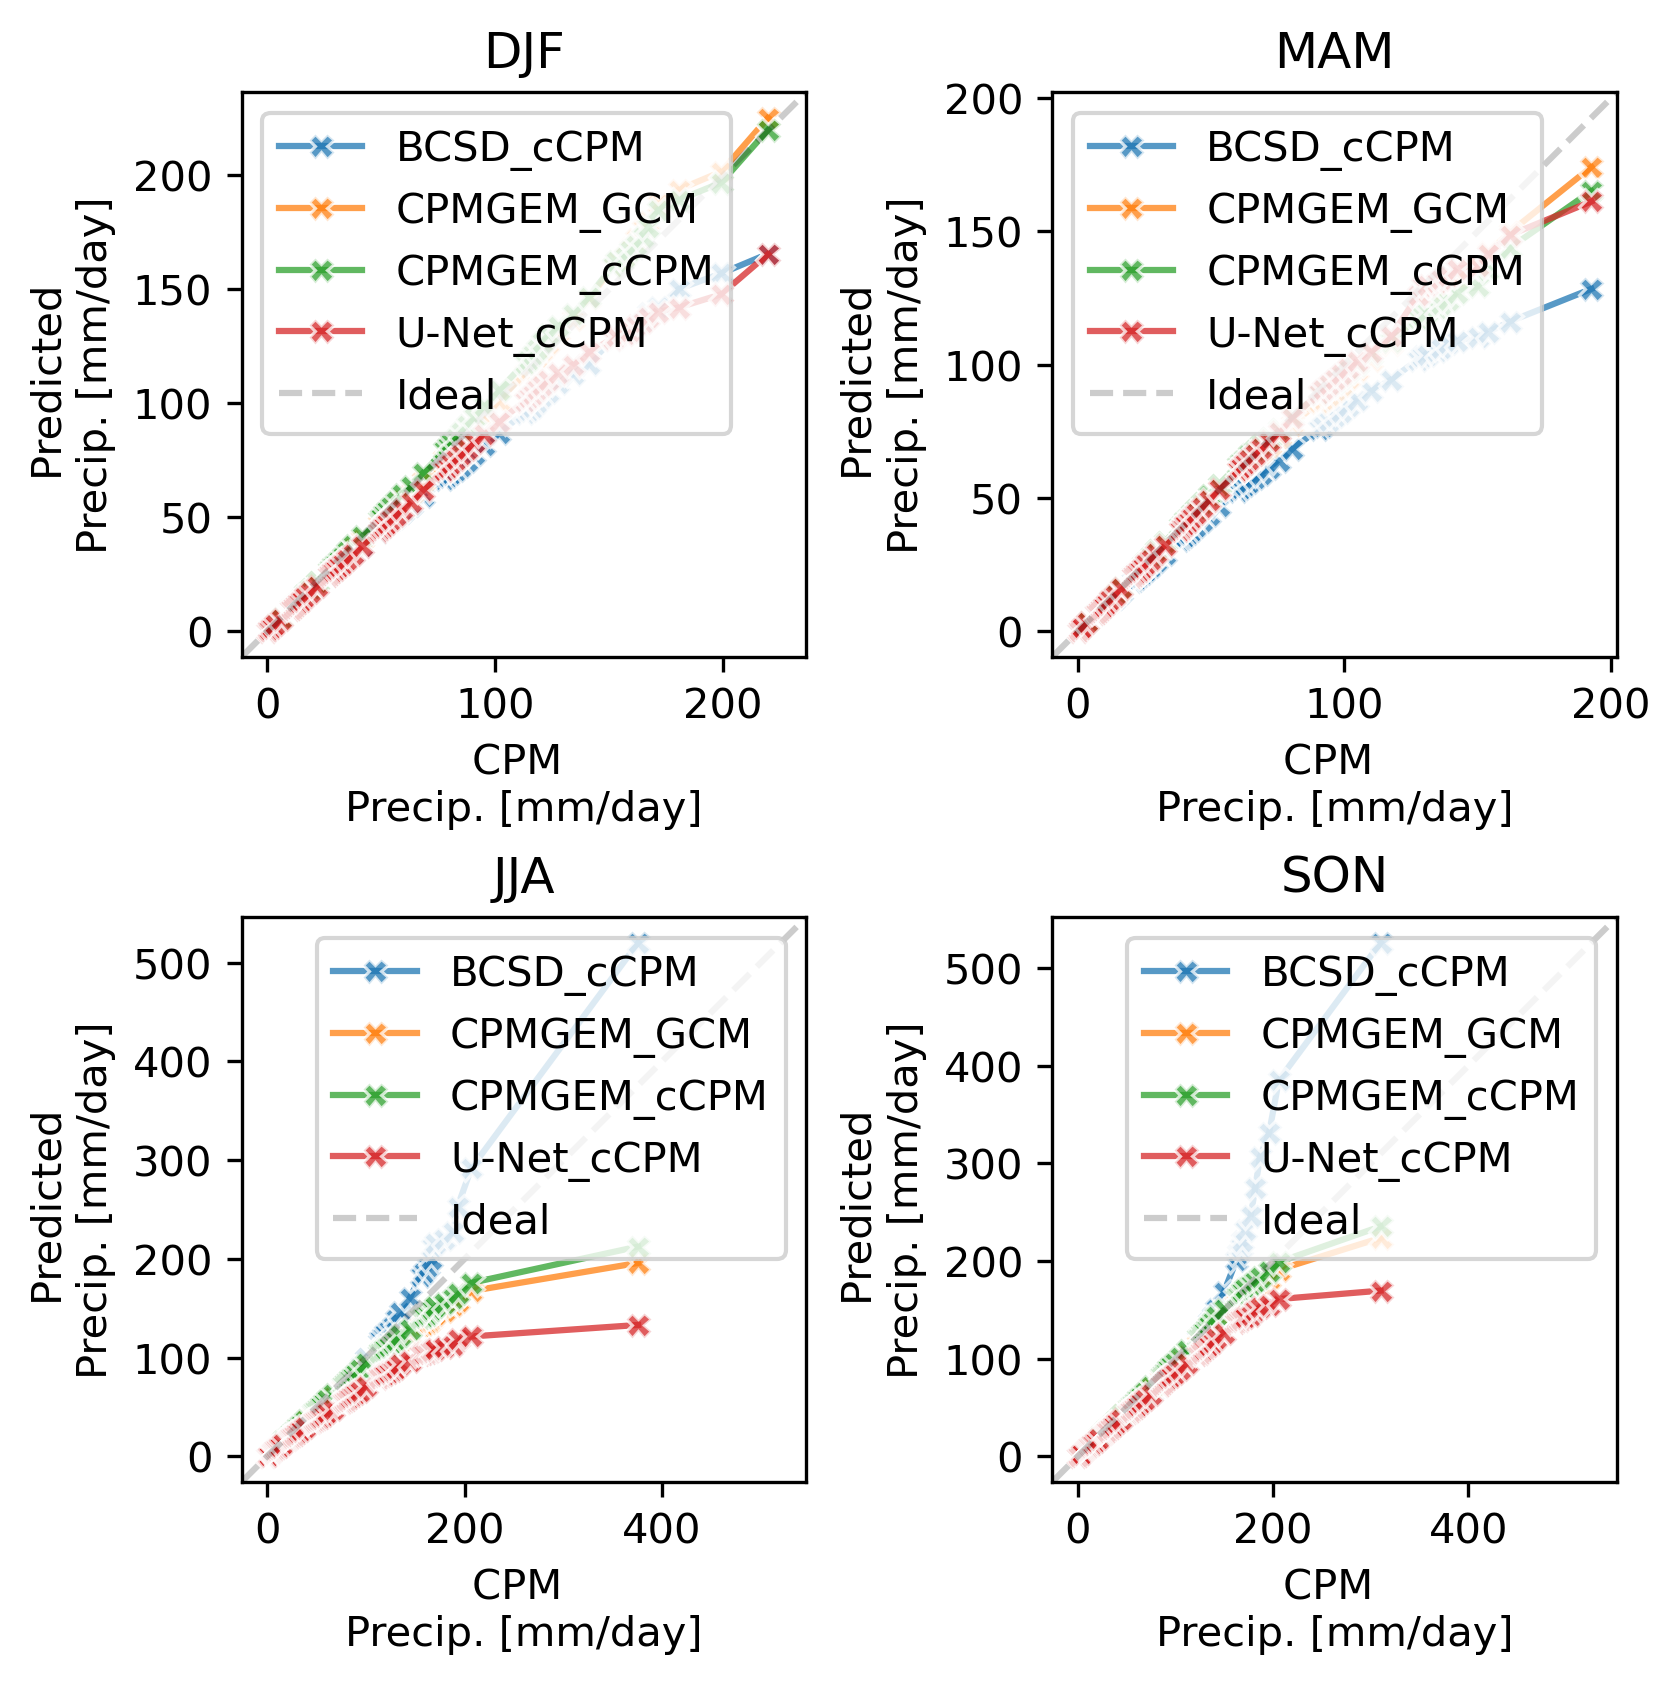

In [ ]:
quantile_dims=["ensemble_member", "time", "grid_latitude", "grid_longitude"]

for var in eval_vars:
    IPython.display.display_markdown(f"### {var}", raw=True)

    fig = plt.figure(layout='constrained', figsize=(5.5, 5.5))
    axd = fig.subplot_mosaic(np.array(["DJF", "MAM", "JJA", "SON"]).reshape(2,2))

    for season, season_ds in VAR_DAS[var].groupby("time.season"):
        season_cpm_da = season_ds[f"target_{var}"]

        quantiles = reasonable_quantiles(season_cpm_da)
        season_cpm_quantiles = season_cpm_da.quantile(quantiles, dim=quantile_dims).rename("target_q")

        season_pred_da = season_ds[f"pred_{var}"]
        season_pred_quantiles = season_pred_da.quantile(quantiles, dim=quantile_dims).rename("pred_q")

        xlabel = f"CPM \n{xr.plot.utils.label_from_attrs(da=season_cpm_da)}"
        ylabel = f"Predicted \n{xr.plot.utils.label_from_attrs(da=season_pred_da)}"

        qq_plot(axd[season], season_cpm_quantiles, season_pred_quantiles, title=season, xlabel=xlabel, ylabel=ylabel)

    plt.show()